
#### 4.4 模型选择、欠拟合和过拟合
机器学习的目标是发现模式（Pattern），这些模式捕捉到了训练集中潜在的总体规律。我们希望这些模式能够推广到训练集之外的数据上，即泛化，可以泛化的模式是机器学习的根本问题。
- 过拟合（Overfitting）：模型在训练数据上拟合的比潜在分布中更接近的现象。
- 正则化（Regularization）：用于对抗过拟合的技术。

##### 4.4.1 训练误差和泛化误差
- 训练误差（Training Error）：模型在训练数据集上计算得到的误差。
- 泛化误差（Generalization Error）：模型应用在同样从原始样本的分布中抽取无限多样本数据时，模型误差的期望。在实际应用中，使用独立的测试集来估计泛化误差。
1. 统计学习理论
- 独立同分布假设（Independent Identical Distribution Assumption）：对数据进行抽样的过程没有进行“记忆”。
2. 模型复杂性
影响模型泛化的因素：
- 可调整参数的数量（自由度），当自由度很大时，模型往往容易过拟合；
- 参数的取值：当权重的取值范围较大时，模型容易过拟合；
- 训练样本的数量：即使模型很简单，也很容易过拟合只包含一两个样本的数据集吗，而过拟合一个有数百万个样本的数据集则需要一个极其灵活的模型。

##### 4.4.2 模型选择
- 模型选择：在机器学习中在评估几个候选模型后选择最终的模型的过程。
1. 验证集
常见做法是将数据分成3份，除了训练集和测试集外引入验证数据集（Validation Dataset）或验证集（Validation Set）。
2. K折交叉验证
当训练数据稀缺时，无法提供足够的数据来构成一个合适的验证集，通常引入一个解决发难：K折交叉验证。首先，原始数据被分成K个不重叠的子集；然后执行K次模型训练和验证，每次在K-1个子集上进行训练，并在剩余的一个子集上进行验证；最后通过对K次实验的结果取平均值来估计训练误差和验证误差。

##### 4.4.3 过拟合和欠拟合
- 欠拟合（Underfitting）：模型过于简单，导致训练误差和验证误差都很小。
1. 模型复杂性
2. 数据集大小
训练数据量越大，泛化误差通常会减小。

##### 4.4.4 多项式回归

In [11]:
import math
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt


1. 生成数据集
使用以下三阶多项式来生成训练数据和测试数据标签：
$$y=5+1.2x-3.4\frac{x^2}{2!}+5.6\frac{x^3}{3!}+\epsilon，其中\epsilon\sim N(0,0.1^2)$$
为训练集和测试集各生成100个样本。

In [12]:
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练集和测试集的大小
true_w = np.zeros(max_degree)   # 分配内存空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_train, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)    # gamma(n) = (n-1)!
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

# NumPyndarray -> tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32) for x in [true_w, features, poly_features, labels]]
features[:2], poly_features[:2, :], labels[:2]

(tensor([[1.2895],
         [0.8427]]),
 tensor([[1.0000e+00, 1.2895e+00, 8.3145e-01, 3.5740e-01, 1.1522e-01, 2.9716e-02,
          6.3866e-03, 1.1765e-03, 1.8965e-04, 2.7173e-05, 3.5041e-06, 4.1079e-07,
          4.4144e-08, 4.3788e-09, 4.0333e-10, 3.4674e-11, 2.7946e-12, 2.1198e-13,
          1.5187e-14, 1.0307e-15],
         [1.0000e+00, 8.4274e-01, 3.5510e-01, 9.9753e-02, 2.1016e-02, 3.5423e-03,
          4.9753e-04, 5.9899e-05, 6.3099e-06, 5.9084e-07, 4.9792e-08, 3.8147e-09,
          2.6790e-10, 1.7367e-11, 1.0454e-12, 5.8734e-14, 3.0936e-15, 1.5336e-16,
          7.1800e-18, 3.1847e-19]]),
 tensor([5.6971, 5.3864]))

2. 对模型进行训练和测试
分别定义一个损失函数和训练函数。

In [23]:
from Functions import *
def evaluate_loss(net, data_iter, loss):    #@save
    """评估给定数据集上模型的损失"""
    metric = Accumulator(2)
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]


def train(train_features, test_features, train_labels, test_labels, num_epochs=400):    #@save
    global net
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
    test_iter = load_array((test_features, test_labels.reshape(-1, 1)), batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = Animator(xlabel='epoch', ylabel='loss', yscale='log', xlim=[1, num_epochs], ylim=[1e-3, 1e2], legend=['train', 'test'])
    for epoch in range(num_epochs):
        train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    # print('weight:', net[0].weight.data.numpy())

3. 三阶多项式函数拟合（正常）
首先使用三阶多项式函数拟合，选择多项式特征中选择前四个维度。

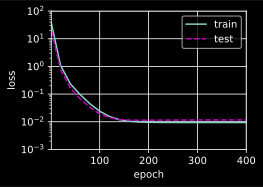

In [24]:
train(poly_features[:n_train, :4], poly_features[n_train:, :4], labels[:n_train], labels[n_train:])

In [25]:
print('weight:', net[0].weight.data.numpy())

weight: [[ 4.9935575  1.1924946 -3.395403   5.6007304]]


4. 线性函数拟合（欠拟合）

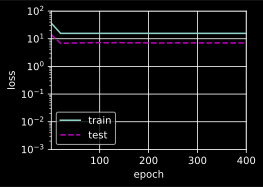

In [27]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2], labels[:n_train], labels[n_train:])

In [29]:
print('weight:', net[0].weight.data.numpy())

weight: [[2.9841244 4.7667217]]


5. 高阶多项式函数拟合（过拟合）

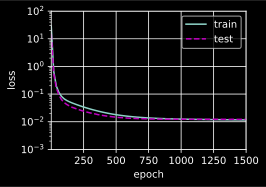

In [30]:
train(poly_features[:n_train, :], poly_features[n_train:, :], labels[:n_train], labels[n_train:], num_epochs=1500)

In [31]:
print('weight:', net[0].weight.data.numpy())

weight: [[ 5.0030937   1.2746255  -3.43965     5.1713157   0.11302888  1.1906115
   0.0429261   0.12785193  0.18862706  0.20068596 -0.16580577 -0.20048454
   0.06726991 -0.17117548  0.09473832 -0.038286    0.00806915  0.11785477
  -0.11333199 -0.03441858]]


#### 4.5 权重衰减
对阶数进行优化。

##### 4.5.1 范数与权重衰减
- 权重衰减是广泛使用的正则化技术，亦称$L_2$正则化。通过函数与零的距离来度量函数的复杂度。
- 通过线性函数$f(\mathbf{x})=\mathbf{w}^T\mathbf{x}$的权重$\mathbf{w}$的范数来度量函数的复杂度。要保证权重向量较小，最常用的方法是将其范数作为惩罚项添加到最小化损失中，将原来的训练目标最小化训练标签的**预测损失**，调整为**最小化预测损失和惩罚项之和**。
- 使用**正则化常数**$\lambda$（非负超参数）来描述这种权衡，使用验证数据拟合：
$$L(\mathbf{w},b)+\frac{\lambda}{2}\|\mathbf{w}\|_2^2$$
- $L_2$正则化回归的小批量随机梯度下降更新如下式：
$$\mathbf{w}\leftarrow(1-\eta\lambda)\mathbf{w}-\frac{\eta}{|B|}\sum_{i\in B}\mathbf{x}^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)}+b-y^{(i)})$$

##### 4.5.2 高位线性回归
生成数据：
$$y=0.05+\sum_{i=1}^d 0.01x_i+\epsilon，其中\epsilon\sim N(0,0.1^2)$$
其中输入维度$d=200$，训练集20个样本，以凸显过拟合的效果。

In [1]:
from Functions import *
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = synthetic_data(true_w, true_b, n_train)
train_iter = load_array(train_data, batch_size)
test_data = synthetic_data(true_w, true_b, n_test)
test_iter = load_array(test_data, batch_size, is_train=False)

##### 4.5.3 从零开始实现
1. 初始化模型参数

In [2]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

2. 定义$L_2$范数惩罚项

In [3]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

3. 定义训练代码实现

In [4]:
def train(lambd):
    w, b = init_params()
    net = lambda X: X @ w + b
    loss = lambda y_hat, y: (y_hat - y) ** 2 / 2
    num_epochs, lr = 100, 0.003
    animator = Animator(xlabel='wpochs', ylabel='loss', yscale='log', xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss), evaluate_loss(net, test_iter, loss)))

4. 忽略正则化直接训练
使用```lambd = 0```禁用权重衰减，出现过拟合。

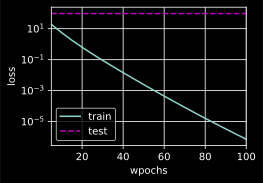

In [5]:
train(lambd=0)

5. 使用权重衰减

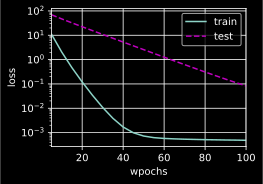

In [12]:
train(lambd=3)

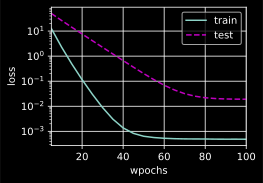

In [13]:
train(lambd=5)

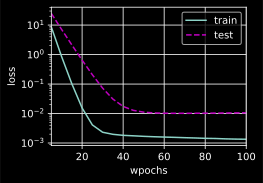

In [14]:
train(lambd=10)

##### 4.5.4 简洁实现

In [17]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear((num_inputs), 1))     # 定义模型
    for param in net.parameters():                      # 所有参数正态分布初始化
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')                 # 损失函数，均方误差
    num_epochs, lr = 100, 0.003
    # 优化器定义，设置偏置参数不衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight, 'weight_decay': wd},
        {"params":net[0].bias}],lr=lr)
    animator = Animator(xlabel='epochs', ylabel='loss', yscale='log', xlim=[5, num_epochs], legend=['train', 'test'])

    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()     # 梯度清零
            l = loss(net(X), y)     # 前向计算
            l.mean().backward()     # 转成标量，自动求梯度
            trainer.step()          # 更新参数
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (evaluate_loss(net, train_iter, loss),
                         evaluate_loss(net, test_iter, loss)))
    global ans
    ans = net[0].weight.norm().item()

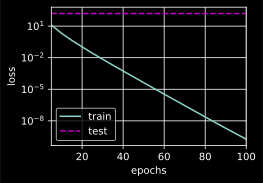

In [22]:
train_concise(0)

In [23]:
print("||w|| = ", ans)

||w|| =  12.32715129852295


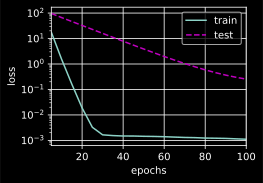

In [24]:
train_concise(3)

In [25]:
print("||w|| = ", ans)

||w|| =  0.35576483607292175


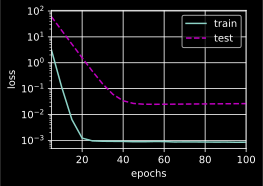

In [26]:
train_concise(10)

In [27]:
print("||w|| = ", ans)

||w|| =  0.018787860870361328


#### 4.6 暂退法
希望模型深度挖掘特征，即将权重分赛道许多特征中，而不是过于依赖少数潜在的虚假关联，**令权重的值取自均值为0的高斯分布**。

##### 4.6.1 重新审视过拟合
- 线性模型没有考虑到特征之间的交互作用，对于每个特征，线性模型必须指定正的或负的权重而忽视其他特征性。
- **偏差-方差权衡（Bias-Variance Tradeoff）**：泛化性和灵活性之间的权衡。
- 深度神经网络不局限于单独查看每个特征，而是学习特征之间的交互。

##### 4.6.2 扰动的稳健性
- 暂退法：再计算后续层之前向网络的每一层注入噪声，以增强输入-输出映射上的平滑性。
- 共适应性：神经网路过拟合与每次一层都依赖前一层的激活值有关。认为暂退法可以破坏共适应性。
- 将高斯噪声添加到线性模型的输入中，在每次训练迭代中，将均值为0的分布$\epsilon\sim N(0, \sigma^2)$中抽样噪声并添加到输入$\mathbf{x}$中，从而产生扰动$\mathbf{x'}=\mathbf{x}+\epsilon$，期望是$E[\mathbf{x'}]=\mathbf{x}$。
- 在标准暂退法正则化中，通过按保留的节点的分数进行规范化来消除每一层的偏差，即每个中间激活值$h$以暂退概率$p$被随机变量$h'$替换，如下所示：
$$
h'=
\begin{cases}
0, & \text{概率为 } p \\
\frac{h}{1-p}, & \text{else}
\end{cases}
$$

##### 4.6.3 实践中的暂退法
- 在训练过程中，暂退法会随机丢弃一些神经元的输出，以防止模型过度依赖某些特定的神经元。

##### 4.6.4 从零开始实现
- 实现单层的暂退法函数，从均匀分布$U[0,1]$中抽取样本，样本数与这层神经网路的维度一致，保留对应样本大于%p%的节点，把剩下的节点丢弃。
- 实现```dropout_layer```函数，以```dropout```的概率丢弃张量输入```X```中的元素，重新缩放剩余部分。

In [30]:
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1:
        return torch.zeros_like(X)
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

X = torch.arange(16, dtype=torch.float32).reshape((2, 8))
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  2.,  0.,  6.,  8., 10., 12., 14.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


1. 定义模型参数
继续使用Fashion-MNIST数据集，定义具有两个隐藏层的感知机，每个隐藏层包含256个隐藏单元。

In [31]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

2. 定义模型
将暂退法应用在每个隐藏层的输出，并且可以为每一层分别设置暂退概率。本例尽在训练期间生效，两个隐藏层的暂退概率分别为0.2和0.5。

In [40]:
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2, is_training=True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只有在训练模型时使用暂退法
        if self.training == True:
            H1 = dropout_layer(H1, dropout1)    # 在第一个全连接层后添加一个暂退层
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            H2 = dropout_layer(H2, dropout1)    # 在第二个全连接层后添加一个暂退层
        out = self.lin3(H2)
        return out
net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

3. 训练和测试

加载Fashion-MNIST数据集。

In [38]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='D:/Algorithm_and_Deep_Learning/DeepLearningNotes/data', train=True, download=False, transform=transform)
test_dataset = datasets.FashionMNIST(root='D:/Algorithm_and_Deep_Learning/DeepLearningNotes/data', train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print(len(train_dataset), len(test_dataset))

60000 10000


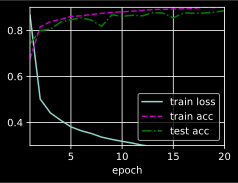

In [39]:
num_epochs, lr, batch_size = 20, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = train_loader, test_loader
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

##### 4.6.5 简洁实现
在每个全连接层之后添加一个暂退层，将暂退概率作为唯一的参数传递给它的构造函数。在训练时，暂退层根据指定的暂退概率随即丢弃上一层的输出作为下一层的输入；在测试时，暂退层直接将上一层的输出作为下一层的输入。

In [41]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout1),
                    nn.Linear(256, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout2),
                    nn.Linear(256, 10))
def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
net.apply(init_weight)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

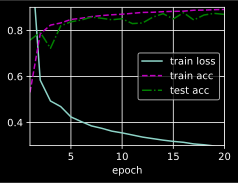

In [42]:
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)